In [1]:
# ==============================================
# 📘 BYOL + DANN Ablation (No Meta Regulation)
# EfficientNet-B0 Backbone 
# ==============================================

!pip install --quiet --no-deps byol-pytorch==0.8.2 timm opencv-python-headless tqdm scikit-learn

import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================================
# Stage 1 — BYOL Pretraining (Self-Supervised)
# ===============================================
from byol_pytorch import BYOL

unlabeled_root = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography/train"

class UnlabeledDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        for subdir, _, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(subdir, f))
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform_unlabeled = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.ToTensor()
])

unlabeled_ds = UnlabeledDataset(unlabeled_root, transform=transform_unlabeled)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=32, shuffle=True, num_workers=4)
print("Unlabeled samples:", len(unlabeled_ds))

# EfficientNet-B0 backbone
backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

ssl_model = BYOL(backbone, image_size=224, projection_size=256, projection_hidden_size=1024).to(device)
opt_ssl = optim.Adam(ssl_model.parameters(), lr=1e-4)

epochs = 10  # shorter pretraining for ablation
for epoch in range(epochs):
    ssl_model.train()
    total_loss = 0
    for imgs in tqdm(unlabeled_loader, desc=f"BYOL Epoch {epoch+1}/{epochs}"):
        imgs = imgs.to(device)
        loss = ssl_model(imgs)
        opt_ssl.zero_grad()
        loss.backward()
        opt_ssl.step()
        total_loss += loss.item() * imgs.size(0)
    print(f"Epoch {epoch+1} loss = {total_loss/len(unlabeled_ds):.4f}")

torch.save(backbone.state_dict(), "efficientnet_b0_byol_backbone.pth")
print("✅ Saved BYOL-pretrained EfficientNet-B0 backbone.")

# ===============================================
# Stage 2 — Fine-tuning (Supervised)
# ===============================================
root_path = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography"
train_dir = os.path.join(root_path, "train")
val_dir = os.path.join(root_path, "valid")
test_dir = os.path.join(root_path, "test")

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform_train)
val_ds = datasets.ImageFolder(val_dir, transform=transform_eval)
test_ds = datasets.ImageFolder(test_dir, transform=transform_eval)
class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

# Load BYOL pretrained weights if available
if os.path.exists("efficientnet_b0_byol_backbone.pth"):
    state = torch.load("efficientnet_b0_byol_backbone.pth", map_location=device)
    backbone.load_state_dict(state, strict=False)
    print("✅ Loaded BYOL pretrained EfficientNet-B0 backbone.")
else:
    print("⚠️ Using random initialization.")

head = nn.Sequential(
    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

class FullModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        feats = self.backbone(x)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        return self.head(feats)

model = FullModel(backbone, head).to(device)

# Freeze early layers to reduce overfitting
for name, p in model.backbone.named_parameters():
    if "features.6" not in name and "features.7" not in name:
        p.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Fine-tune {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    print(f"Epoch {epoch+1} acc={correct/total:.4f}")

torch.save(model.state_dict(), "finetuned_effnetb0_byol_nometa.pth")

# ===============================================
# Stage 3 — DANN (Domain Alignment with GRL)
# ===============================================
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None
def grad_reverse(x, alpha=1.0):
    return GradReverse.apply(x, alpha)

backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

if os.path.exists("efficientnet_b0_byol_backbone.pth"):
    state = torch.load("efficientnet_b0_byol_backbone.pth", map_location=device)
    backbone.load_state_dict(state, strict=False)
    print("✅ Loaded BYOL weights for DANN.")

backbone = backbone.to(device)
task_head = nn.Sequential(
    nn.Linear(1280, 512), nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, num_classes)
).to(device)
domain_disc = nn.Sequential(
    nn.Linear(1280, 512), nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, 1)
).to(device)

criterion_cls = nn.CrossEntropyLoss()
criterion_domain = nn.BCEWithLogitsLoss()
opt_task = optim.AdamW(list(backbone.parameters()) + list(task_head.parameters()), lr=1e-4)
opt_dom = optim.AdamW(domain_disc.parameters(), lr=1e-4)
lambda_domain = 0.1

def grl_lambda(epoch, max_epoch):
    p = float(epoch)/float(max_epoch)
    return 2.0/(1.0+math.exp(-10*p))-1.0

num_epochs = 10
for epoch in range(num_epochs):
    backbone.train(); task_head.train(); domain_disc.train()
    total_task, total_dom, correct, total = 0,0,0,0
    alpha = grl_lambda(epoch, num_epochs)
    for imgs, labels in tqdm(train_loader, desc=f"DANN Epoch {epoch+1}/{num_epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        half = imgs.size(0)//2
        domain_labels = torch.zeros(imgs.size(0), 1, device=device)
        domain_labels[half:] = 1.0
        shuffled_imgs = imgs.clone()
        shuffled_imgs[half:] = torch.flip(imgs[half:], dims=[0])

        # --- Train domain discriminator ---
        opt_dom.zero_grad()
        feats = backbone(shuffled_imgs)
        if feats.dim() > 2: feats = torch.flatten(feats, 1)
        dom_logits = domain_disc(feats.detach())
        loss_dom = criterion_domain(dom_logits, domain_labels)
        loss_dom.backward()
        opt_dom.step()

        # --- Train backbone + classifier ---
        opt_task.zero_grad()
        feats = backbone(imgs)
        if feats.dim() > 2: feats = torch.flatten(feats, 1)
        task_logits = task_head(feats)
        loss_task = criterion_cls(task_logits, labels)
        dom_rev_logits = domain_disc(grad_reverse(feats, alpha))
        loss_domain_rev = criterion_domain(dom_rev_logits, domain_labels)
        total_loss = loss_task + lambda_domain * loss_domain_rev
        total_loss.backward()
        opt_task.step()

        total_task += loss_task.item()*imgs.size(0)
        total_dom += loss_dom.item()*imgs.size(0)
        preds = task_logits.argmax(1)
        correct += (preds==labels).sum().item()
        total += imgs.size(0)

    print(f"Epoch [{epoch+1}/{num_epochs}] TaskLoss={total_task/len(train_ds):.4f} "
          f"DomLoss={total_dom/len(train_ds):.4f} TrainAcc={correct/total:.4f}")

torch.save({
    "backbone": backbone.state_dict(),
    "task_head": task_head.state_dict(),
    "domain_disc": domain_disc.state_dict()
}, "effnetb0_dann_nometa.pth")
print("✅ DANN completed (no meta regulation).")


Device: cuda
Unlabeled samples: 25136


BYOL Epoch 1/10: 100%|██████████| 786/786 [05:54<00:00,  2.22it/s]


Epoch 1 loss = 1.0948


BYOL Epoch 2/10: 100%|██████████| 786/786 [05:57<00:00,  2.20it/s]


Epoch 2 loss = 1.0346


...

Epoch [8/10] TaskLoss=0.2681 DomLoss=0.6941 TrainAcc=0.9081


DANN Epoch 9/10: 100%|██████████| 786/786 [02:59<00:00,  4.38it/s]


Epoch [9/10] TaskLoss=0.2542 DomLoss=0.6938 TrainAcc=0.9111


DANN Epoch 10/10: 100%|██████████| 786/786 [02:59<00:00,  4.37it/s]


Epoch [10/10] TaskLoss=0.2419 DomLoss=0.6938 TrainAcc=0.9169
✅ DANN completed (no meta regulation).


Device: cuda


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


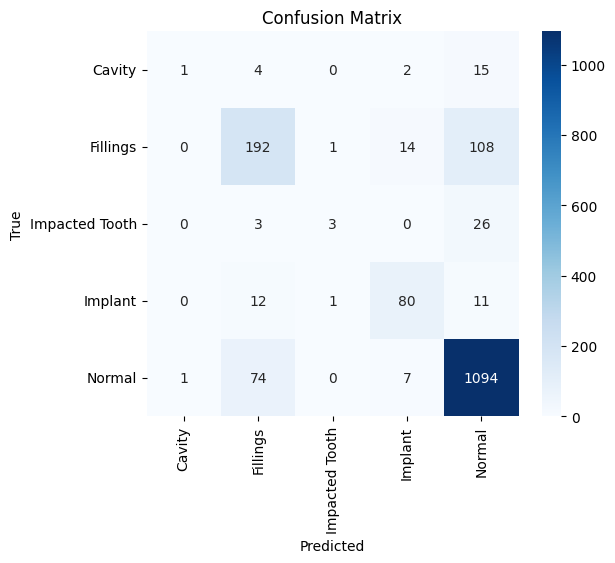


=== Classification Report ===
                precision    recall  f1-score   support

        Cavity     0.5000    0.0455    0.0833        22
      Fillings     0.6737    0.6095    0.6400       315
Impacted Tooth     0.6000    0.0938    0.1622        32
       Implant     0.7767    0.7692    0.7729       104
        Normal     0.8724    0.9303    0.9004      1176

      accuracy                         0.8308      1649
     macro avg     0.6846    0.4896    0.5118      1649
  weighted avg     0.8182    0.8308    0.8174      1649


=== Disease Category-wise Metrics ===
  Disease Category  Precision    Recall  F1-score  Support
0           Cavity   0.500000  0.045455  0.083333       22
1         Fillings   0.673684  0.609524  0.640000      315
2   Impacted Tooth   0.600000  0.093750  0.162162       32
3          Implant   0.776699  0.769231  0.772947      104
4           Normal   0.872408  0.930272  0.900412     1176

=== Specificity per Class ===
Cavity: 0.9994
Fillings: 0.9303
Impact

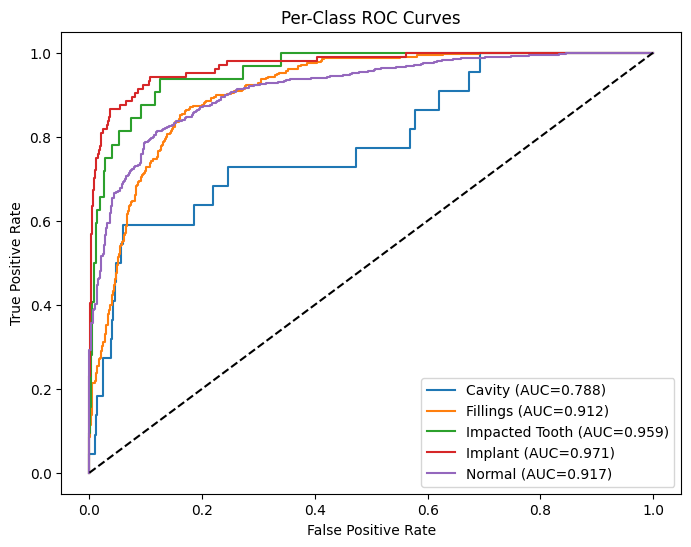

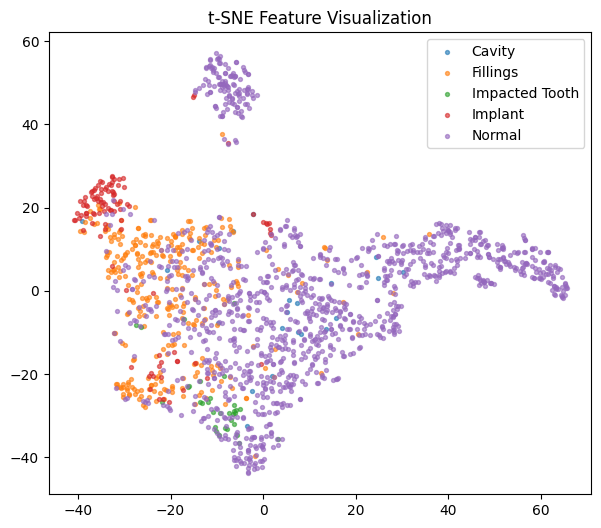


Overall Test Accuracy-No Meta-Regulation: 0.8308


In [9]:
# ==============================
#  Evaluation 
# ==============================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------
# 1️⃣ Load test dataset
# ------------------------------
# Make sure test_ds is already defined
bs = 32
test_loader = DataLoader(test_ds, batch_size=bs, shuffle=True, num_workers=6)

# ------------------------------
# 2️⃣ Load trained model
# ------------------------------
ckpt = torch.load("/kaggle/working/effnetb0_dann_nometa.pth", map_location=device)


# ------------------------------
# 3️⃣ Collect predictions & features
# ------------------------------
y_true = []
y_logits = []
feats_all = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        feats = model.backbone(imgs)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        logits = model.head(feats)

        y_true.append(labels.cpu().numpy())
        y_logits.append(logits.cpu().numpy())
        feats_all.append(feats.cpu().numpy())

y_true = np.concatenate(y_true)
y_logits = np.concatenate(y_logits)
y_prob = F.softmax(torch.tensor(y_logits), dim=1).numpy()
y_pred = np.argmax(y_prob, axis=1)

# ------------------------------
# 4️⃣ Confusion matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------
# 5️⃣ Classification report & per-class metrics
# ------------------------------
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Optional: tabular per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
report_df = pd.DataFrame({
    "Disease Category": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})
print("\n=== Disease Category-wise Metrics ===")
print(report_df)

# ------------------------------
# 6️⃣ Per-class specificity
# ------------------------------
specificity_per_class = []
for i in range(len(class_names)):
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    FP = cm[:, i].sum() - cm[i, i]
    specificity = TN / (TN + FP)
    specificity_per_class.append(specificity)

print("\n=== Specificity per Class ===")
for cname, spec in zip(class_names, specificity_per_class):
    print(f"{cname}: {spec:.4f}")

# ------------------------------
# 7️⃣ Per-class ROC curves
# ------------------------------
y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
plt.figure(figsize=(8,6))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves")
plt.legend()
plt.show()

# ------------------------------
# 8️⃣ Feature visualization (t-SNE)
# ------------------------------
feats_all = np.concatenate(feats_all)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
fe2 = tsne.fit_transform(feats_all)

plt.figure(figsize=(7,6))
for i, cname in enumerate(class_names):
    sel = y_true == i
    plt.scatter(fe2[sel,0], fe2[sel,1], label=cname, s=8, alpha=0.6)
plt.legend()
plt.title("t-SNE Feature Visualization")
plt.show()

# ------------------------------
# ✅ Done
# ------------------------------
acc = (y_pred == y_true).mean()
print(f"\nOverall Test Accuracy-No Meta-Regulation: {acc:.4f}")
